Computing global mean CO2...
CO2: 23 files found
Computing global mean zo2min...
zo2min: 23 files found
--------------------------------------------------------------------------------
Linear regression: zo2min = slope × CO2 + intercept
n        = 2700
slope    = -0.012501 m ppm-1
intercept= 65.802 m
R2       = 0.0645
p-value  = 4.940e-41
--------------------------------------------------------------------------------


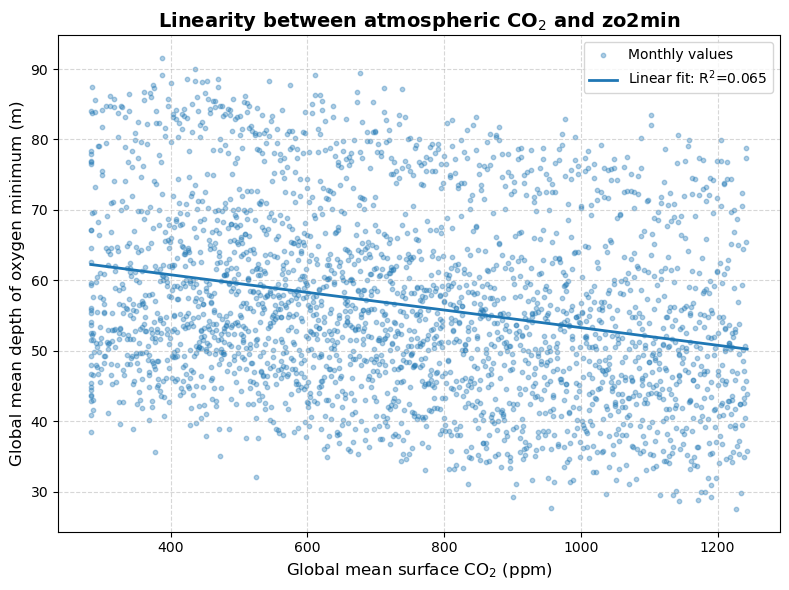

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings
from scipy.stats import linregress

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010"

CO2_PATTERN = (
    f"{BASE_DIR}/co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

ZO2MIN_PATTERN = (
    f"{BASE_DIR}/zo2min_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
)

# ============================================================
# Function: compute global mean CO2 ppm
# ============================================================

def compute_global_mean_co2_ppm(file_pattern):

    files = sorted(glob.glob(file_pattern))
    print(f"CO2: {len(files)} files found")

    if len(files) == 0:
        raise FileNotFoundError("No CO2 files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    co2 = ds["co2"]

    if "plev" in co2.dims:
        co2 = co2.isel(plev=-1, drop=True)

    weights = np.cos(np.deg2rad(ds["lat"]))
    weights = weights.fillna(0)

    co2_gm = co2.weighted(weights).mean(
        dim=["lat", "lon"],
        skipna=True
    )

    co2_ppm = (co2_gm * 1e6).compute()
    co2_ppm.name = "CO2_ppm"

    ds.close()

    return co2_ppm

# ============================================================
# Function: compute global mean zo2min
# ============================================================

def compute_global_mean_zo2min(file_pattern):

    files = sorted(glob.glob(file_pattern))
    print(f"zo2min: {len(files)} files found")

    if len(files) == 0:
        raise FileNotFoundError("No zo2min files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    zo2min = ds["zo2min"]

    # Area weights using 2D latitude
    lat = ds["latitude"].where(np.abs(ds["latitude"]) <= 90)
    weights = np.cos(np.deg2rad(lat))

    ocean_mask = zo2min.isel(time=0).notnull()
    weights = weights.where(ocean_mask).fillna(0)

    zo2min_gm = zo2min.weighted(weights).mean(
        dim=["j", "i"],
        skipna=True
    ).compute()

    zo2min_gm.name = "zo2min_global_mean"

    ds.close()

    return zo2min_gm

# ============================================================
# Compute time series
# ============================================================

print("Computing global mean CO2...")
co2_ppm = compute_global_mean_co2_ppm(CO2_PATTERN)

print("Computing global mean zo2min...")
zo2min_gm = compute_global_mean_zo2min(ZO2MIN_PATTERN)

# ============================================================
# Align CO2 and zo2min
# ============================================================

co2_aligned, zo2min_aligned = xr.align(
    co2_ppm,
    zo2min_gm,
    join="inner"
)

x = co2_aligned.values
y = zo2min_aligned.values

valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

# ============================================================
# Linear regression
# ============================================================

reg = linregress(x, y)
y_fit = reg.slope * x + reg.intercept
r2 = reg.rvalue ** 2

idx = np.argsort(x)

print("-" * 80)
print("Linear regression: zo2min = slope × CO2 + intercept")
print(f"n        = {len(x)}")
print(f"slope    = {reg.slope:.6f} m ppm-1")
print(f"intercept= {reg.intercept:.3f} m")
print(f"R2       = {r2:.4f}")
print(f"p-value  = {reg.pvalue:.3e}")
print("-" * 80)

# ============================================================
# Plot: CO2 vs zo2min
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    s=10,
    alpha=0.35,
    label="Monthly values"
)

plt.plot(
    x[idx],
    y_fit[idx],
    linewidth=2,
    label=f"Linear fit: R$^2$={r2:.3f}"
)

plt.xlabel("Global mean surface CO$_2$ (ppm)", fontsize=12)
plt.ylabel("Global mean depth of oxygen minimum (m)", fontsize=12)

plt.title(
    "Linearity between atmospheric CO$_2$ and zo2min",
    fontsize=14,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig(
    "linear_relationship_CO2_vs_global_mean_zo2min.png",
    dpi=300
)

plt.show()

In [4]:
import xarray as xr
import numpy as np
import glob
import os
import time
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

IN_DIR = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010"

AREACELLO_FILE = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "areacello_Ofx_NorESM2-LM_esm-up2p0_r1i1p1f1_gn.nc"
)

OUT_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL"
)

os.makedirs(OUT_DIR, exist_ok=True)

THRESHOLD_MG_L = 2.0
O2_MOLAR_MASS_G_MOL = 31.998
THRESHOLD_MOL_M3 = THRESHOLD_MG_L / O2_MOLAR_MASS_G_MOL

files = sorted(glob.glob(
    f"{IN_DIR}/o2_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
))

print(f"Found {len(files)} O2 files")
print(f"Threshold: {THRESHOLD_MG_L} mg L-1 = {THRESHOLD_MOL_M3:.6f} mol m-3")
print(f"Output directory: {OUT_DIR}")

# ============================================================
# Open areacello once
# ============================================================

ds_area = xr.open_dataset(AREACELLO_FILE)
area = ds_area["areacello"]

# ============================================================
# Loop over all files
# ============================================================

total_start = time.time()

for n, infile in enumerate(files, start=1):

    start = time.time()

    fname = os.path.basename(infile)
    outfile = os.path.join(
        OUT_DIR,
        fname.replace("o2_Omon", "omzvol_2mgL_Omon")
    )

    print("=" * 80)
    print(f"[{n}/{len(files)}] Processing")
    print(f"Input : {infile}")
    print(f"Output: {outfile}")

    if os.path.exists(outfile):
        print("Output already exists. Skipping.")
        continue

    ds = xr.open_dataset(
        infile,
        use_cftime=True,
        chunks={"time": 12, "lev": 10}
    )

    o2 = ds["o2"]

    # Layer thickness from lev_bnds
    dz = ds["lev_bnds"].isel(bnds=1) - ds["lev_bnds"].isel(bnds=0)
    dz.attrs["units"] = "m"

    # volume(lev, j, i)
    volume = (dz * area).fillna(0)
    volume.attrs["units"] = "m3"

    # OMZ volume per horizontal grid cell
    omz_volume = xr.where(
        o2 < THRESHOLD_MOL_M3,
        volume,
        0.0
    ).sum(dim="lev")

    omz_volume.name = "omz_volume"
    omz_volume.attrs["long_name"] = (
        f"Volume of water column with O2 < {THRESHOLD_MG_L} mg L-1"
    )
    omz_volume.attrs["units"] = "m3"
    omz_volume.attrs["threshold_mg_L"] = THRESHOLD_MG_L
    omz_volume.attrs["threshold_mol_m3"] = THRESHOLD_MOL_M3

    out = xr.Dataset(
        {"omz_volume": omz_volume},
        coords={
            "time": ds["time"],
            "j": ds["j"],
            "i": ds["i"],
            "latitude": ds["latitude"],
            "longitude": ds["longitude"],
        },
    )

    out.attrs["description"] = (
        "OMZ volume per horizontal grid cell calculated from raw 3-D o2."
    )
    out.attrs["source_file"] = infile
    out.attrs["areacello_file"] = AREACELLO_FILE
    out.attrs["definition"] = (
        f"Sum of grid-cell volume where o2 < {THRESHOLD_MG_L} mg L-1 "
        f"({THRESHOLD_MOL_M3:.6f} mol m-3)."
    )

    encoding = {
        "omz_volume": {
            "zlib": True,
            "complevel": 4,
            "_FillValue": 1.0e20,
        }
    }

    print("Computing and saving...")
    out.to_netcdf(outfile, encoding=encoding)

    ds.close()

    elapsed = time.time() - start
    print(f"Finished in {elapsed:.2f} sec ({elapsed / 60:.2f} min)")

total_elapsed = time.time() - total_start

ds_area.close()

print("=" * 80)
print("All files processed.")
print(f"Total elapsed time: {total_elapsed:.2f} sec ({total_elapsed / 60:.2f} min)")

Found 23 O2 files
Threshold: 2.0 mg L-1 = 0.062504 mol m-3
Output directory: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL
[1/23] Processing
Input : /nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/o2_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
Output: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
Computing and saving...
Finished in 64.77 sec (1.08 min)
[2/23] Processing
Input : /nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/o2_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_186001-186912.nc
Output: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_186001-186912.nc
Computing and saving...
Finished in 65.08 sec (1.08 min)
[3/23] Processing
Input : /nird/datalake/NS2980K/projects/TipESM/c

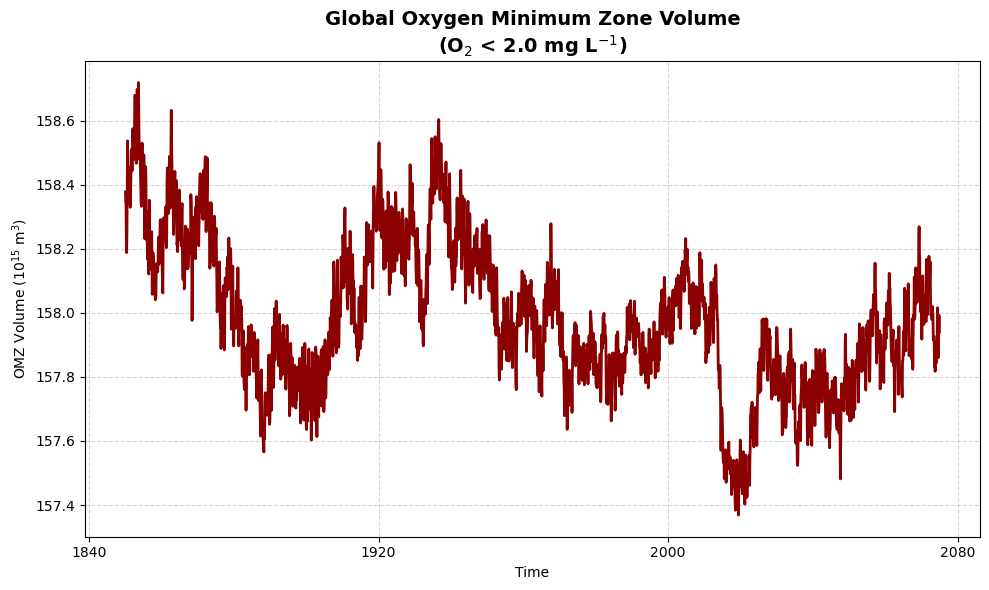

------------------------------------------------------------
Minimum OMZ volume = 157.369 ×10^15 m³
Maximum OMZ volume = 158.719 ×10^15 m³
Change = -0.437 ×10^15 m³
------------------------------------------------------------


In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import glob

# ============================================================
# Open OMZ volume files
# ============================================================

files = sorted(glob.glob(
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/"
    "omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
))

ds = xr.open_mfdataset(
    files,
    combine="by_coords",
    use_cftime=True,
    data_vars="minimal",
    coords="minimal",
    compat="override"
)

# ============================================================
# Global total OMZ volume
# ============================================================

global_omz_volume = (
    ds["omz_volume"]
    .sum(dim=["j", "i"], skipna=True)
    .compute()
)

# Convert to 10^15 m3 for readability
global_omz_volume_Pm3 = global_omz_volume / 1e15

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10,6))

global_omz_volume_Pm3.plot(
    linewidth=2,
    color="darkred"
)

plt.title(
    "Global Oxygen Minimum Zone Volume\n(O$_2$ < 2.0 mg L$^{-1}$)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("OMZ Volume ($10^{15}$ m$^3$)")
plt.xlabel("Time")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    "global_OMZ_volume_timeseries.png",
    dpi=300
)

plt.show()

# ============================================================
# Summary
# ============================================================

print("-" * 60)
print(
    f"Minimum OMZ volume = "
    f"{float(global_omz_volume_Pm3.min()):.3f} ×10^15 m³"
)

print(
    f"Maximum OMZ volume = "
    f"{float(global_omz_volume_Pm3.max()):.3f} ×10^15 m³"
)

print(
    f"Change = "
    f"{float(global_omz_volume_Pm3[-1]-global_omz_volume_Pm3[0]):.3f} ×10^15 m³"
)
print("-" * 60)

Computing CO2...
CO2 files: 23
Computing global total OMZ volume...
OMZ files: 23


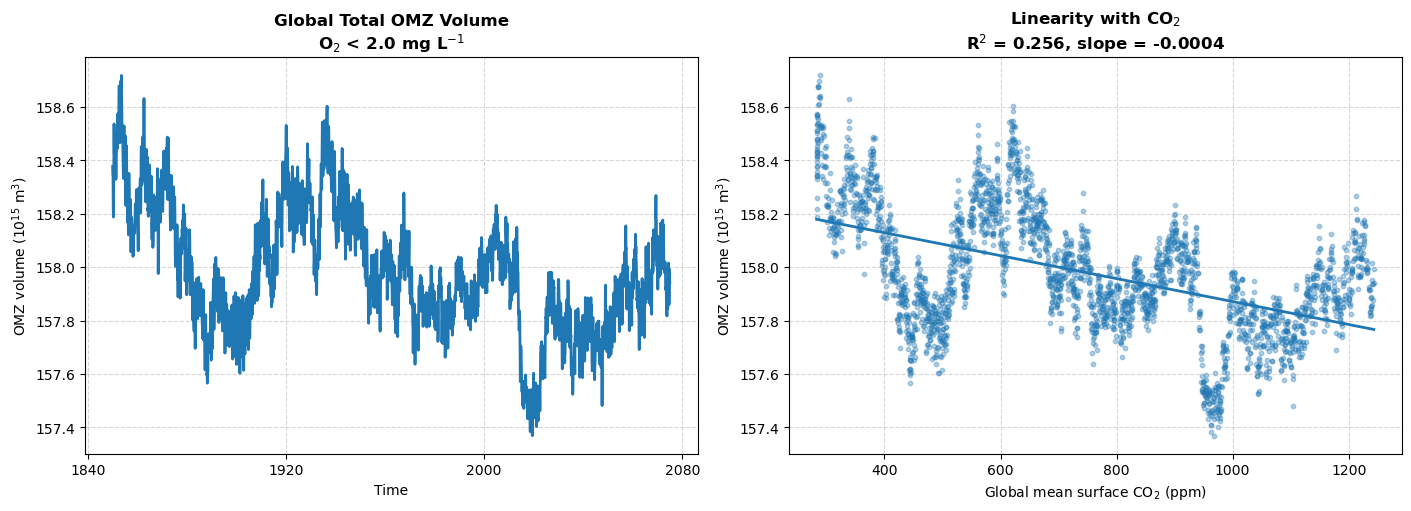

--------------------------------------------------------------------------------
Global OMZ volume = slope × CO2(ppm) + intercept
n        = 2700
slope    = -0.000430 ×10^15 m3 ppm-1
intercept= 158.301282 ×10^15 m3
R2       = 0.2562
p-value  = 1.202e-175
--------------------------------------------------------------------------------


In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings
from scipy.stats import linregress

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

CO2_PATTERN = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

OMZ_PATTERN = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/"
    "omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
)

# ============================================================
# Function: CO2 global mean ppm
# ============================================================

def compute_global_mean_co2_ppm(file_pattern):

    files = sorted(glob.glob(file_pattern))
    print(f"CO2 files: {len(files)}")

    if len(files) == 0:
        raise FileNotFoundError("No CO2 files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    co2 = ds["co2"]

    if "plev" in co2.dims:
        co2 = co2.isel(plev=-1, drop=True)

    weights = np.cos(np.deg2rad(ds["lat"])).fillna(0)

    co2_ppm = (
        co2.weighted(weights)
        .mean(dim=["lat", "lon"], skipna=True)
        * 1e6
    ).compute()

    co2_ppm.name = "co2_ppm"

    ds.close()

    return co2_ppm

# ============================================================
# Function: global total OMZ volume
# ============================================================

def compute_global_total_omz_volume(file_pattern):

    files = sorted(glob.glob(file_pattern))
    print(f"OMZ files: {len(files)}")

    if len(files) == 0:
        raise FileNotFoundError("No OMZ volume files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    omz_volume = ds["omz_volume"]

    # Global sum, units: m3
    global_omz_volume = omz_volume.sum(
        dim=["j", "i"],
        skipna=True
    ).compute()

    global_omz_volume.name = "global_omz_volume"

    ds.close()

    return global_omz_volume

# ============================================================
# Compute series
# ============================================================

print("Computing CO2...")
co2_ppm = compute_global_mean_co2_ppm(CO2_PATTERN)

print("Computing global total OMZ volume...")
omz_global = compute_global_total_omz_volume(OMZ_PATTERN)

# Convert m3 to 10^15 m3 for readability
omz_global_Pm3 = omz_global / 1e15
omz_global_Pm3.name = "global_omz_volume_1e15m3"

# ============================================================
# Align and regression
# ============================================================

co2_aligned, omz_aligned = xr.align(
    co2_ppm,
    omz_global_Pm3,
    join="inner"
)

x = co2_aligned.values
y = omz_aligned.values

valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

reg = linregress(x, y)

y_fit = reg.slope * x + reg.intercept
r2 = reg.rvalue ** 2

idx = np.argsort(x)

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    constrained_layout=True
)

# Time series
omz_global_Pm3.plot(
    ax=axes[0],
    linewidth=2
)

axes[0].set_title(
    "Global Total OMZ Volume\nO$_2$ < 2.0 mg L$^{-1}$",
    fontsize=12,
    fontweight="bold"
)
axes[0].set_ylabel("OMZ volume ($10^{15}$ m$^3$)")
axes[0].set_xlabel("Time")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Linearity scatter
axes[1].scatter(
    x,
    y,
    s=10,
    alpha=0.35
)

axes[1].plot(
    x[idx],
    y_fit[idx],
    linewidth=2
)

axes[1].set_title(
    f"Linearity with CO$_2$\nR$^2$ = {r2:.3f}, slope = {reg.slope:.4f}",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel("Global mean surface CO$_2$ (ppm)")
axes[1].set_ylabel("OMZ volume ($10^{15}$ m$^3$)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.savefig(
    "global_OMZ_volume_timeseries_and_linearity_CO2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Summary
# ============================================================

print("-" * 80)
print("Global OMZ volume = slope × CO2(ppm) + intercept")
print(f"n        = {len(x)}")
print(f"slope    = {reg.slope:.6f} ×10^15 m3 ppm-1")
print(f"intercept= {reg.intercept:.6f} ×10^15 m3")
print(f"R2       = {r2:.4f}")
print(f"p-value  = {reg.pvalue:.3e}")
print("-" * 80)

In [9]:
import xarray as xr
import numpy as np
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

CO2_PATTERN = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

OMZ_PATTERN = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/"
    "omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
)

# ============================================================
# CO2 global mean
# ============================================================

def compute_global_mean_co2_ppm(file_pattern):

    files = sorted(glob.glob(file_pattern))
    print(f"CO2 files: {len(files)}")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    co2 = ds["co2"]

    if "plev" in co2.dims:
        co2 = co2.isel(plev=-1, drop=True)

    weights = np.cos(np.deg2rad(ds["lat"])).fillna(0)

    co2_ppm = (
        co2.weighted(weights)
        .mean(dim=["lat", "lon"], skipna=True)
        * 1e6
    ).compute()

    ds.close()

    return co2_ppm


def r2_1d(x, y):
    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 24:
        return np.nan

    xx = x[valid]
    yy = y[valid]

    if np.nanstd(xx) == 0 or np.nanstd(yy) == 0:
        return np.nan

    r = np.corrcoef(xx, yy)[0, 1]

    return r ** 2

# ============================================================
# Compute CO2 and OMZ R2 map
# ============================================================

print("Computing CO2...")
co2_ppm = compute_global_mean_co2_ppm(CO2_PATTERN)

files = sorted(glob.glob(OMZ_PATTERN))
print(f"OMZ files: {len(files)}")

ds_omz = xr.open_mfdataset(
    files,
    combine="by_coords",
    use_cftime=True,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    chunks={"time": -1}
)

omz = ds_omz["omz_volume"] / 1e15  # optional scaling for numeric stability

co2_aligned, omz_aligned = xr.align(
    co2_ppm,
    omz,
    join="inner"
)

r2_map = xr.apply_ufunc(
    r2_1d,
    co2_aligned,
    omz_aligned,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    dask_gufunc_kwargs={"allow_rechunk": True},
    output_dtypes=[float],
)

print("Computing R2 map...")
r2_map = r2_map.compute()
print("Done.")

r2_map.name = "r2_omz_volume_vs_co2"

Computing CO2...
CO2 files: 23
OMZ files: 23
Computing R2 map...
Done.


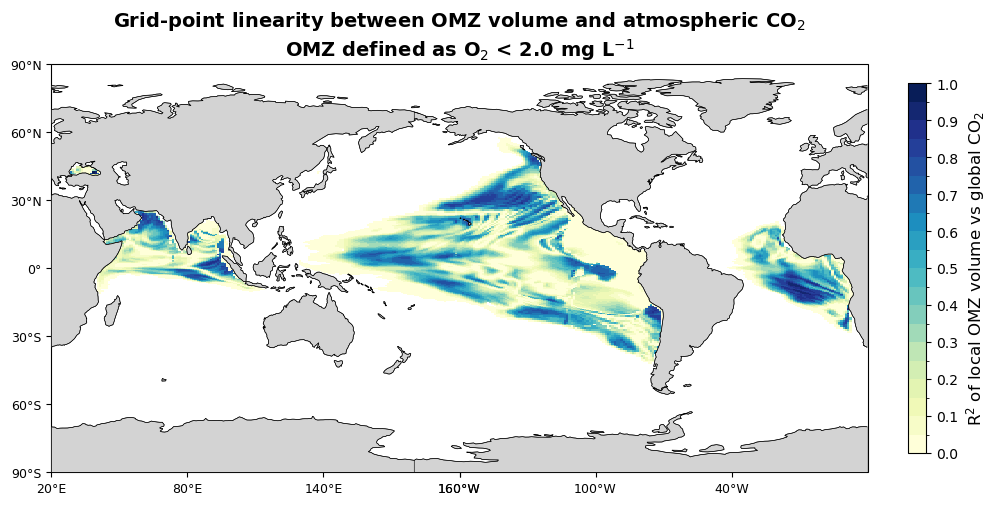

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

levels = np.arange(0, 1.05, 0.05)

cmap = plt.get_cmap("YlGnBu", len(levels) - 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(levels, cmap.N)

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig = plt.figure(figsize=(13, 6))
ax = plt.axes(projection=map_crs)

lon = r2_map["longitude"]
lat = r2_map["latitude"]

pcm = ax.pcolormesh(
    lon,
    lat,
    r2_map,
    transform=data_crs,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax.add_feature(
    cfeature.LAND,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.3,
    zorder=10
)

ax.coastlines(resolution="110m", linewidth=0.5, zorder=11)

ax.set_global()

ax.set_xticks(np.arange(-160, 201, 60), crs=data_crs)
ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

ax.tick_params(labelsize=9)

cbar = plt.colorbar(
    pcm,
    ax=ax,
    boundaries=levels,
    ticks=np.arange(0, 1.1, 0.1),
    spacing="proportional",
    shrink=0.8,
    pad=0.04
)

cbar.set_label(
    "R$^2$ of local OMZ volume vs global CO$_2$",
    fontsize=12
)

plt.title(
    "Grid-point linearity between OMZ volume and atmospheric CO$_2$\n"
    "OMZ defined as O$_2$ < 2.0 mg L$^{-1}$",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    "R2_map_local_OMZ_volume_vs_CO2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Number of files: 23
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc
<xarray.DataArray 'omz_volume' (time: 2700, j: 385, i: 360)>
dask.array<concatenate, shape=(2700, 385, 360), dtype=float64, chunksize=(120, 385, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2074-12-16 12:00:00
  * j          (j) int32 1 2 3 4 5 6 7 8 9 ... 378 379 380 381 382 383 384 385
  * i          (i) int32 1 2 3 4 5 6 7 8 9 ... 353 354 355 356 357 358 359 360
    latitude   (j, i) float64 dask.array<chunksize=(385, 360), meta=np.ndarray>
    longitude  (j, i) float64 dask.array<chunksize=(385, 360), meta=np.ndarray>
Attributes:
    long_name:         Volume of water column with O2 < 

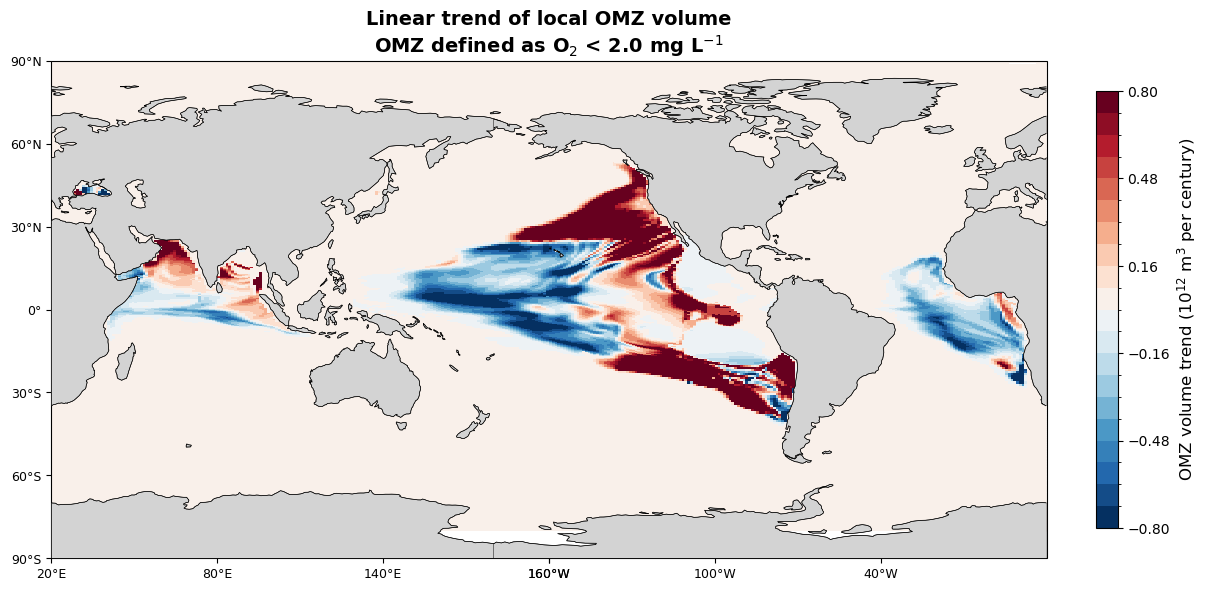

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import glob
import warnings

warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Open OMZ volume files
# ============================================================

files = sorted(glob.glob(
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/omz_volume_2mgL/"
    "omzvol_2mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
))

print("Number of files:", len(files))
print(files[0])
print(files[-1])

ds = xr.open_mfdataset(
    files,
    combine="by_coords",
    use_cftime=True,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    chunks={"time": 120}
)

omz = ds["omz_volume"]

print(omz)

# ============================================================
# Check coordinate names
# ============================================================

print("dims:", omz.dims)
print("coords:", list(omz.coords))

# Usually NorESM ocean grid has:
# dims: time, j, i
# coords: latitude(j,i), longitude(j,i) or lat/lon variants

if "longitude" in ds:
    lon = ds["longitude"]
elif "lon" in ds:
    lon = ds["lon"]
else:
    raise ValueError("Cannot find longitude coordinate.")

if "latitude" in ds:
    lat = ds["latitude"]
elif "lat" in ds:
    lat = ds["lat"]
else:
    raise ValueError("Cannot find latitude coordinate.")

# ============================================================
# Annual mean grid-point OMZ volume
# ============================================================

omz_ann = omz.groupby("time.year").mean("time")

# ============================================================
# Linear trend at each grid point
# unit: omz_volume unit per century
# ============================================================

year = omz_ann["year"]
x = year - year.mean()

trend_omz = (
    (omz_ann * x).sum("year", skipna=True) /
    (x ** 2).sum("year", skipna=True)
) * 100.0

trend_omz.name = "OMZ volume trend"

# Attach 2D lon/lat coordinates for plotting
trend_omz = trend_omz.assign_coords(
    longitude=lon,
    latitude=lat
)

# Optional: convert m3 per century to 10^12 m3 per century
# Uncomment if values are too large
trend_plot = trend_omz / 1e12
trend_plot.name = "OMZ volume trend"

print(trend_plot)

# ============================================================
# Symmetric color range around zero
# ============================================================

valid = trend_plot.values[np.isfinite(trend_plot.values)]

vmax = np.nanpercentile(np.abs(valid), 98)

# Pretty rounding
if vmax >= 10:
    vmax = np.ceil(vmax / 10) * 10
elif vmax >= 1:
    vmax = np.ceil(vmax)
else:
    vmax = np.ceil(vmax * 10) / 10

vmin = -vmax
levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) - 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(levels, cmap.N)

# ============================================================
# Map projection
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig = plt.figure(figsize=(13, 6))
ax = plt.axes(projection=map_crs)

pcm = ax.pcolormesh(
    trend_plot["longitude"],
    trend_plot["latitude"],
    trend_plot,
    transform=data_crs,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax.add_feature(
    cfeature.LAND,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.3,
    zorder=10
)

ax.coastlines(
    resolution="110m",
    linewidth=0.5,
    zorder=11
)

ax.set_global()

ax.set_xticks(np.arange(-160, 201, 60), crs=data_crs)
ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

ax.tick_params(labelsize=9)

cbar = plt.colorbar(
    pcm,
    ax=ax,
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    shrink=0.8,
    pad=0.04
)

cbar.set_label(
    "OMZ volume trend ($10^{12}$ m$^3$ per century)",
    fontsize=12
)

plt.title(
    "Linear trend of local OMZ volume\n"
    "OMZ defined as O$_2$ < 2.0 mg L$^{-1}$",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [12]:
import xarray as xr
import numpy as np
import glob
import os
import time
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

IN_DIR = "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010"

AREACELLO_FILE = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "areacello_Ofx_NorESM2-LM_esm-up2p0_r1i1p1f1_gn.nc"
)

OUT_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL"
)

os.makedirs(OUT_DIR, exist_ok=True)

THRESHOLD_MG_L = 4.6
O2_MOLAR_MASS_G_MOL = 31.998
THRESHOLD_MOL_M3 = THRESHOLD_MG_L / O2_MOLAR_MASS_G_MOL

files = sorted(glob.glob(
    f"{IN_DIR}/o2_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
))

print(f"Found {len(files)} O2 files")
print(f"Threshold: {THRESHOLD_MG_L} mg L-1 = {THRESHOLD_MOL_M3:.6f} mol m-3")
print(f"Output directory: {OUT_DIR}")

# ============================================================
# Open areacello once
# ============================================================

ds_area = xr.open_dataset(AREACELLO_FILE)
area = ds_area["areacello"]

# ============================================================
# Loop over all files
# ============================================================

total_start = time.time()

for n, infile in enumerate(files, start=1):

    start = time.time()

    fname = os.path.basename(infile)
    outfile = os.path.join(
        OUT_DIR,
        fname.replace("o2_Omon", "lowO2vol_4p6mgL_Omon")
    )

    print("=" * 80)
    print(f"[{n}/{len(files)}] Processing")
    print(f"Input : {infile}")
    print(f"Output: {outfile}")

    if os.path.exists(outfile):
        print("Output already exists. Skipping.")
        continue

    ds = xr.open_dataset(
        infile,
        use_cftime=True,
        chunks={"time": 12, "lev": 10}
    )

    o2 = ds["o2"]

    # Layer thickness from lev_bnds
    dz = ds["lev_bnds"].isel(bnds=1) - ds["lev_bnds"].isel(bnds=0)
    dz.attrs["units"] = "m"

    # volume(lev, j, i)
    volume = (dz * area).fillna(0)
    volume.attrs["units"] = "m3"

    # Low-O2 volume per horizontal grid cell
    low_o2_volume = xr.where(
        o2 < THRESHOLD_MOL_M3,
        volume,
        0.0
    ).sum(dim="lev")

    low_o2_volume.name = "low_o2_volume"
    low_o2_volume.attrs["long_name"] = (
        f"Volume of water column with O2 < {THRESHOLD_MG_L} mg L-1"
    )
    low_o2_volume.attrs["units"] = "m3"
    low_o2_volume.attrs["threshold_mg_L"] = THRESHOLD_MG_L
    low_o2_volume.attrs["threshold_mol_m3"] = THRESHOLD_MOL_M3

    out = xr.Dataset(
        {"low_o2_volume": low_o2_volume},
        coords={
            "time": ds["time"],
            "j": ds["j"],
            "i": ds["i"],
            "latitude": ds["latitude"],
            "longitude": ds["longitude"],
        },
    )

    out.attrs["description"] = (
        "Low-O2 volume per horizontal grid cell calculated from raw 3-D o2."
    )
    out.attrs["source_file"] = infile
    out.attrs["areacello_file"] = AREACELLO_FILE
    out.attrs["definition"] = (
        f"Sum of grid-cell volume where o2 < {THRESHOLD_MG_L} mg L-1 "
        f"({THRESHOLD_MOL_M3:.6f} mol m-3)."
    )

    encoding = {
        "low_o2_volume": {
            "zlib": True,
            "complevel": 4,
            "_FillValue": 1.0e20,
        }
    }

    print("Computing and saving...")
    out.to_netcdf(outfile, encoding=encoding)

    ds.close()

    elapsed = time.time() - start
    print(f"Finished in {elapsed:.2f} sec ({elapsed / 60:.2f} min)")

total_elapsed = time.time() - total_start

ds_area.close()

print("=" * 80)
print("All files processed.")
print(f"Total elapsed time: {total_elapsed:.2f} sec ({total_elapsed / 60:.2f} min)")

Found 23 O2 files
Threshold: 4.6 mg L-1 = 0.143759 mol m-3
Output directory: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL
[1/23] Processing
Input : /nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/o2_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
Output: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
Computing and saving...
Finished in 64.93 sec (1.08 min)
[2/23] Processing
Input : /nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/o2_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_186001-186912.nc
Output: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_186001-186912.nc
Computing and saving...
Finished in 65.29 sec (1.09 min)
[3/23] Processing
Input : /nird/datalake/NS298

Computing CO2...
CO2 files: 23
Computing global total low-O2 volume...
Low-O2 files: 23


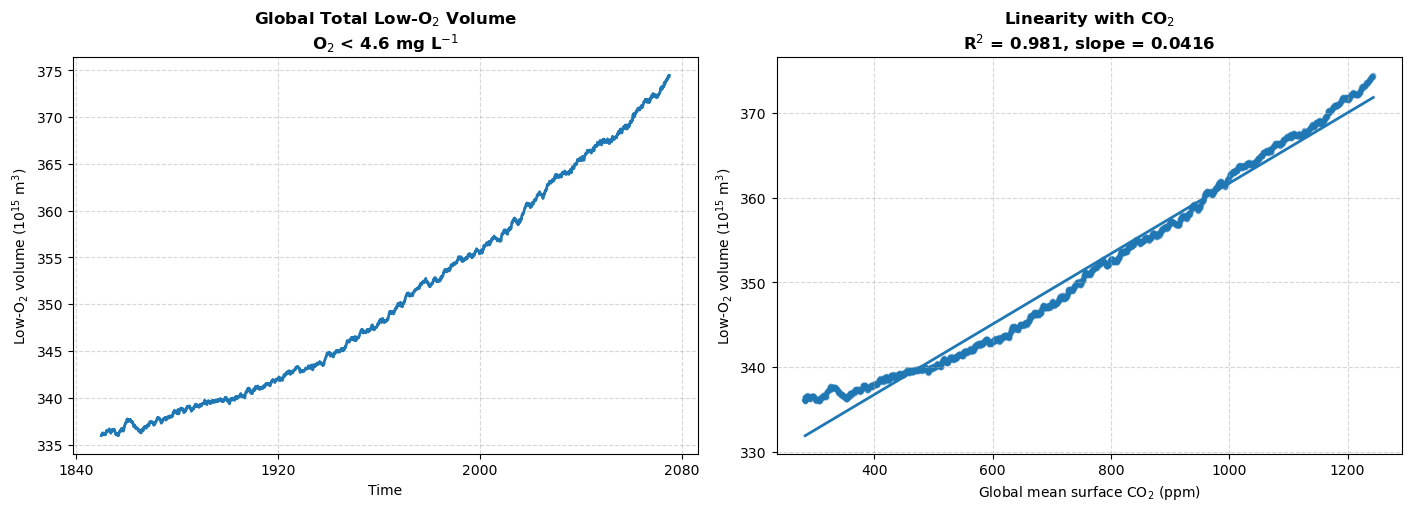

--------------------------------------------------------------------------------
Global low-O2 volume = slope × CO2(ppm) + intercept
Threshold= 4.6 mg L-1
n        = 2700
slope    = 0.041627 ×10^15 m3 ppm-1
intercept= 320.110431 ×10^15 m3
R2       = 0.9806
p-value  = 0.000e+00
--------------------------------------------------------------------------------


In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings
from scipy.stats import linregress

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

CO2_PATTERN = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

LOWO2_PATTERN = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/"
    "lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
)

# ============================================================
# Function: CO2 global mean ppm
# ============================================================

def compute_global_mean_co2_ppm(file_pattern):

    files = sorted(glob.glob(file_pattern))
    print(f"CO2 files: {len(files)}")

    if len(files) == 0:
        raise FileNotFoundError("No CO2 files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    co2 = ds["co2"]

    if "plev" in co2.dims:
        co2 = co2.isel(plev=-1, drop=True)

    weights = np.cos(np.deg2rad(ds["lat"])).fillna(0)

    co2_ppm = (
        co2.weighted(weights)
        .mean(dim=["lat", "lon"], skipna=True)
        * 1e6
    ).compute()

    co2_ppm.name = "co2_ppm"

    ds.close()

    return co2_ppm

# ============================================================
# Function: global total low-O2 volume
# ============================================================

def compute_global_total_low_o2_volume(file_pattern):

    files = sorted(glob.glob(file_pattern))
    print(f"Low-O2 files: {len(files)}")

    if len(files) == 0:
        raise FileNotFoundError("No low-O2 volume files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    low_o2_volume = ds["low_o2_volume"]

    # Global sum, units: m3
    global_low_o2_volume = low_o2_volume.sum(
        dim=["j", "i"],
        skipna=True
    ).compute()

    global_low_o2_volume.name = "global_low_o2_volume"

    ds.close()

    return global_low_o2_volume

# ============================================================
# Compute series
# ============================================================

print("Computing CO2...")
co2_ppm = compute_global_mean_co2_ppm(CO2_PATTERN)

print("Computing global total low-O2 volume...")
low_o2_global = compute_global_total_low_o2_volume(LOWO2_PATTERN)

# Convert m3 to 10^15 m3 for readability
low_o2_global_Pm3 = low_o2_global / 1e15
low_o2_global_Pm3.name = "global_low_o2_volume_1e15m3"

# ============================================================
# Align and regression
# ============================================================

co2_aligned, low_o2_aligned = xr.align(
    co2_ppm,
    low_o2_global_Pm3,
    join="inner"
)

x = co2_aligned.values
y = low_o2_aligned.values

valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

reg = linregress(x, y)

y_fit = reg.slope * x + reg.intercept
r2 = reg.rvalue ** 2

idx = np.argsort(x)

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    constrained_layout=True
)

# Time series
low_o2_global_Pm3.plot(
    ax=axes[0],
    linewidth=2
)

axes[0].set_title(
    "Global Total Low-O$_2$ Volume\nO$_2$ < 4.6 mg L$^{-1}$",
    fontsize=12,
    fontweight="bold"
)
axes[0].set_ylabel("Low-O$_2$ volume ($10^{15}$ m$^3$)")
axes[0].set_xlabel("Time")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Linearity scatter
axes[1].scatter(
    x,
    y,
    s=10,
    alpha=0.35
)

axes[1].plot(
    x[idx],
    y_fit[idx],
    linewidth=2
)

axes[1].set_title(
    f"Linearity with CO$_2$\nR$^2$ = {r2:.3f}, slope = {reg.slope:.4f}",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel("Global mean surface CO$_2$ (ppm)")
axes[1].set_ylabel("Low-O$_2$ volume ($10^{15}$ m$^3$)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.savefig(
    "global_lowO2_volume_4p6mgL_timeseries_and_linearity_CO2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Summary
# ============================================================

print("-" * 80)
print("Global low-O2 volume = slope × CO2(ppm) + intercept")
print(f"Threshold= 4.6 mg L-1")
print(f"n        = {len(x)}")
print(f"slope    = {reg.slope:.6f} ×10^15 m3 ppm-1")
print(f"intercept= {reg.intercept:.6f} ×10^15 m3")
print(f"R2       = {r2:.4f}")
print(f"p-value  = {reg.pvalue:.3e}")
print("-" * 80)

In [15]:
import xarray as xr
import numpy as np
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

CO2_PATTERN = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

LOWO2_PATTERN = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/"
    "lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
)

# ============================================================
# Functions
# ============================================================

def compute_global_mean_co2_ppm(file_pattern):
    files = sorted(glob.glob(file_pattern))
    print(f"CO2 files: {len(files)}")

    if len(files) == 0:
        raise FileNotFoundError("No CO2 files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    co2 = ds["co2"]

    if "plev" in co2.dims:
        co2 = co2.isel(plev=-1, drop=True)

    weights = np.cos(np.deg2rad(ds["lat"])).fillna(0)

    co2_ppm = (
        co2.weighted(weights)
        .mean(dim=["lat", "lon"], skipna=True)
        * 1e6
    ).compute()

    co2_ppm.name = "co2_ppm"

    ds.close()

    return co2_ppm


def r2_1d(x, y):
    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 24:
        return np.nan

    xx = x[valid]
    yy = y[valid]

    if np.nanstd(xx) == 0 or np.nanstd(yy) == 0:
        return np.nan

    r = np.corrcoef(xx, yy)[0, 1]

    return r ** 2

# ============================================================
# Load CO2
# ============================================================

print("Computing CO2...")
co2_ppm = compute_global_mean_co2_ppm(CO2_PATTERN)

# ============================================================
# Load low-O2 volume
# ============================================================

low_o2_files = sorted(glob.glob(LOWO2_PATTERN))
print(f"Low-O2 files: {len(low_o2_files)}")

if len(low_o2_files) == 0:
    raise FileNotFoundError("No low-O2 volume files found.")

ds_low = xr.open_mfdataset(
    low_o2_files,
    combine="by_coords",
    use_cftime=True,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    chunks={"time": -1}
)

low_o2_volume = ds_low["low_o2_volume"]

# Scaling does not affect R2.
low_o2_volume = low_o2_volume / 1e15

# ============================================================
# Align time and fix chunk structure
# ============================================================

co2_aligned, low_o2_aligned = xr.align(
    co2_ppm,
    low_o2_volume,
    join="inner"
)

co2_aligned = co2_aligned.chunk({"time": -1})
low_o2_aligned = low_o2_aligned.chunk({"time": -1})

print(f"Aligned time length: {co2_aligned.sizes['time']}")

# ============================================================
# Compute grid-point R2
# ============================================================

print("Computing grid-point R2 map...")

r2_map = xr.apply_ufunc(
    r2_1d,
    co2_aligned,
    low_o2_aligned,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

r2_map = r2_map.compute()
r2_map.name = "r2_low_o2_volume_4p6mgL_vs_co2"

r2_map = r2_map.assign_coords(
    latitude=ds_low["latitude"],
    longitude=ds_low["longitude"]
)

print("Done.")
print(r2_map)

Computing CO2...
CO2 files: 23
Low-O2 files: 23
Aligned time length: 2700
Computing grid-point R2 map...
Done.
<xarray.DataArray 'r2_low_o2_volume_4p6mgL_vs_co2' (j: 385, i: 360)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * j          (j) int32 1 2 3 4 5 6 7 8 9 ... 378 379 380 381 382 383 384 385
  * i          (i) int32 1 2 3 4 5 6 7 8 9 ... 353 354 355 356 357 358 359 360
    latitude   (j, i) float64 dask.array<chunksize=(385, 360), meta=np.ndarray>
    longitude  (j, i) float64 dask.array<chunksize=(385, 360), meta=np.ndarray>


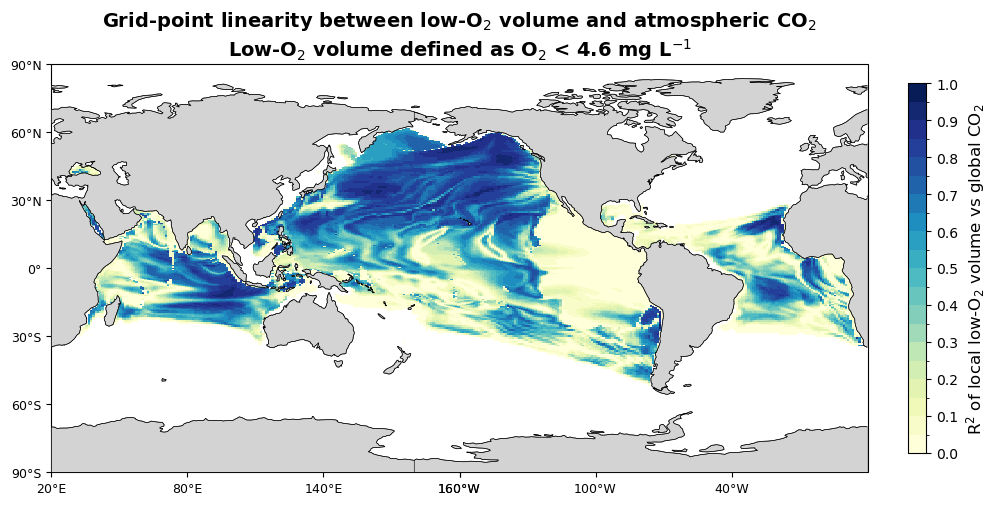

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker

# ============================================================
# Plot R2 map
# ============================================================

levels = np.arange(0, 1.05, 0.05)

cmap = plt.get_cmap("YlGnBu", len(levels) - 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(levels, cmap.N)

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig = plt.figure(figsize=(13, 6))
ax = plt.axes(projection=map_crs)

pcm = ax.pcolormesh(
    r2_map["longitude"],
    r2_map["latitude"],
    r2_map,
    transform=data_crs,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax.add_feature(
    cfeature.LAND,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.3,
    zorder=10
)

ax.coastlines(resolution="110m", linewidth=0.5, zorder=11)
ax.set_global()

ax.set_xticks(np.arange(-160, 201, 60), crs=data_crs)
ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

ax.tick_params(labelsize=9)

cbar = plt.colorbar(
    pcm,
    ax=ax,
    boundaries=levels,
    ticks=np.arange(0, 1.1, 0.1),
    spacing="proportional",
    shrink=0.8,
    pad=0.04
)

cbar.set_label(
    "R$^2$ of local low-O$_2$ volume vs global CO$_2$",
    fontsize=12
)

plt.title(
    "Grid-point linearity between low-O$_2$ volume and atmospheric CO$_2$\n"
    "Low-O$_2$ volume defined as O$_2$ < 4.6 mg L$^{-1}$",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    "R2_map_local_lowO2_volume_4p6mgL_vs_CO2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Number of files: 23
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc
<xarray.DataArray 'low_o2_volume' (time: 2700, j: 385, i: 360)>
dask.array<concatenate, shape=(2700, 385, 360), dtype=float64, chunksize=(120, 385, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2074-12-16 12:00:00
  * j          (j) int32 1 2 3 4 5 6 7 8 9 ... 378 379 380 381 382 383 384 385
  * i          (i) int32 1 2 3 4 5 6 7 8 9 ... 353 354 355 356 357 358 359 360
    latitude   (j, i) float64 dask.array<chunksize=(385, 360), meta=np.ndarray>
    longitude  (j, i) float64 dask.array<chunksize=(385, 360), meta=np.ndarray>
Attributes:
    long_name:         Volume of wate

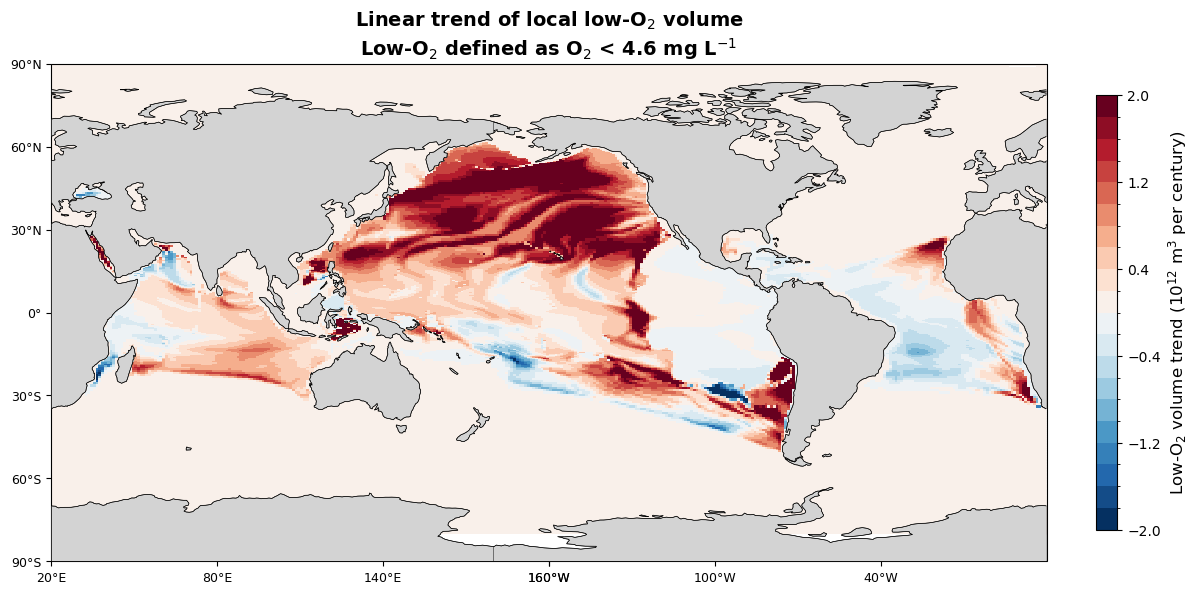

In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import glob
import warnings

warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Open 4.6 mg L-1 low-O2 volume files
# ============================================================

files = sorted(glob.glob(
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/lowO2_volume_4p6mgL/"
    "lowO2vol_4p6mgL_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
))

print("Number of files:", len(files))
print(files[0])
print(files[-1])

ds = xr.open_mfdataset(
    files,
    combine="by_coords",
    use_cftime=True,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    chunks={"time": 120}
)

low_o2 = ds["low_o2_volume"]

print(low_o2)

# ============================================================
# Coordinates
# ============================================================

lon = ds["longitude"]
lat = ds["latitude"]

# ============================================================
# Annual mean grid-point low-O2 volume
# ============================================================

low_o2_ann = low_o2.groupby("time.year").mean("time")

# ============================================================
# Linear trend at each grid point
# unit: m3 per century
# ============================================================

year = low_o2_ann["year"]
x = year - year.mean()

trend_low_o2 = (
    (low_o2_ann * x).sum("year", skipna=True) /
    (x ** 2).sum("year", skipna=True)
) * 100.0

trend_low_o2.name = "Low-O2 volume trend"

trend_low_o2 = trend_low_o2.assign_coords(
    longitude=lon,
    latitude=lat
)

# Convert m3 per century to 10^12 m3 per century
trend_plot = trend_low_o2 / 1e12
trend_plot.name = "Low-O2 volume trend"

print(trend_plot)

# ============================================================
# Symmetric color range around zero
# ============================================================

valid = trend_plot.values[np.isfinite(trend_plot.values)]

vmax = np.nanpercentile(np.abs(valid), 98)

if vmax >= 10:
    vmax = np.ceil(vmax / 10) * 10
elif vmax >= 1:
    vmax = np.ceil(vmax)
else:
    vmax = np.ceil(vmax * 10) / 10

vmin = -vmax
levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) - 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(levels, cmap.N)

# ============================================================
# Map projection
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig = plt.figure(figsize=(13, 6))
ax = plt.axes(projection=map_crs)

pcm = ax.pcolormesh(
    trend_plot["longitude"],
    trend_plot["latitude"],
    trend_plot,
    transform=data_crs,
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax.add_feature(
    cfeature.LAND,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.3,
    zorder=10
)

ax.coastlines(
    resolution="110m",
    linewidth=0.5,
    zorder=11
)

ax.set_global()

ax.set_xticks(np.arange(-160, 201, 60), crs=data_crs)
ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

ax.tick_params(labelsize=9)

cbar = plt.colorbar(
    pcm,
    ax=ax,
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    shrink=0.8,
    pad=0.04
)

cbar.set_label(
    "Low-O$_2$ volume trend ($10^{12}$ m$^3$ per century)",
    fontsize=12
)

plt.title(
    "Linear trend of local low-O$_2$ volume\n"
    "Low-O$_2$ defined as O$_2$ < 4.6 mg L$^{-1}$",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()